# 03 – Baseline Model and Model Comparison

**Project:** AI-Powered Project Planning & Risk Forecasting Platform

This notebook develops and compares machine learning models to predict **project risk levels**.

Objectives:

1. Build a **baseline model**
2. Train several machine learning models
3. Compare model performance
4. Identify the best model for deployment

Target variable:

**Outcome_Risk_Level**

The models evaluated include:

- Logistic Regression (baseline)
- Random Forest
- Gradient Boosting

Evaluation metrics:

- Accuracy
- Precision
- Recall
- F1 Score

In [1]:
# Core libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

## Load Dataset

We begin by loading the historical project portfolio dataset used in the previous notebooks.

This dataset contains both the target outcome and the project-level features that may help predict risk.

In [2]:
project_df = pd.read_csv("../data/project_portfolio_history.csv")

project_df.head()

,Project_ID,Portfolio_Segment,Region,Delivery_Model,Planning_Mode,Complexity_Score,Planned_Duration_Days,Actual_Duration_Days,Delay_Days,Delay_Flag,...,Critical_Path_Task_Count,Vendor_Count,Change_Order_Count,Resource_Buffer_Pct,Weather_Risk_Index,Procurement_Risk_Index,Stakeholder_Alignment_Score,Requirements_Volatility_Score,Forecast_Error_Days,Outcome_Risk_Level
0,P001,Public Sector,South,Design-Build,Spreadsheet,69,301,296,-5,On Time,...,12,11,4,8.3,5.0,35.1,68.1,31.7,3,Low
1,P002,Infrastructure,Central,Design-Build,Spreadsheet,63,266,267,1,Delayed,...,11,8,7,12.0,10.3,7.0,60.2,56.6,1,Low
2,P003,Commercial,North,Agile Hybrid,Spreadsheet,68,304,304,0,On Time,...,14,10,4,4.4,40.9,72.5,52.9,43.3,2,Medium
3,P004,Commercial,West,EPC,Spreadsheet,50,244,245,1,Delayed,...,10,9,2,11.2,22.4,52.3,57.7,35.6,1,Low
4,P005,Industrial,South,Design-Build,Manual,61,292,299,7,Delayed,...,10,5,7,2.4,35.2,25.8,53.5,44.2,11,Low


## Define the Target Variable

The target for this notebook is:

`Outcome_Risk_Level`

This variable represents the final risk classification of each project.

Predicting this label is useful because it can help project managers identify potentially risky projects **earlier in the planning process**, rather than waiting until delays or overruns occur.

In [3]:
target = "Outcome_Risk_Level"

## Encode the Target Variable

Machine learning models generally require the target variable to be represented numerically.

We therefore convert the categorical risk labels into encoded numerical values.

In [4]:
encoder = LabelEncoder()

project_df[target] = encoder.fit_transform(project_df[target])

project_df[target].head()

0    1
1    1
2    2
3    1
4    1
Name: Outcome_Risk_Level, dtype: int64

## Select Input Features

Next, we define the features that will be used to predict project risk.

These variables were chosen because they describe key aspects of project planning and execution, such as:

- complexity
- schedule
- cost performance
- resource allocation
- external dependencies
- volatility and alignment risks

Together, they provide a reasonable starting point for supervised learning.

In [5]:
features = [

"Complexity_Score",
"Planned_Duration_Days",
"Delay_Days",
"Budget_Overrun_Pct",
"Team_Size",
"Critical_Path_Task_Count",
"Vendor_Count",
"Change_Order_Count",
"Resource_Buffer_Pct",
"Weather_Risk_Index",
"Procurement_Risk_Index",
"Stakeholder_Alignment_Score",
"Requirements_Volatility_Score",
"Forecast_Error_Days"

]

X = project_df[features]

y = project_df[target]

## Train/Test Split

To evaluate model performance properly, we split the dataset into:

- a **training set** for learning patterns
- a **test set** for evaluating generalization

This allows us to assess how well each model performs on unseen data.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

Some models, especially linear models such as Logistic Regression, are sensitive to feature scale.

To ensure fair training for the baseline model, we standardize the input variables using `StandardScaler`.

Tree-based models do not strictly require scaling, but scaling is important for the baseline setup.

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline Model – Logistic Regression

We start with **Logistic Regression** as the baseline model.

A baseline model is important because it provides a simple benchmark against which more advanced models can be compared.

If more complex models do not improve meaningfully over the baseline, then added complexity may not be justified.

In [10]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

log_predictions = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test, log_predictions)

print(f"Logistic Regression Accuracy: {log_accuracy:.3f}")

Logistic Regression Accuracy: 0.778


## Logistic Regression Evaluation

Accuracy alone is not sufficient to understand model performance.

We also examine:

- precision
- recall
- F1 score

These metrics provide a more complete view of how well the model performs across risk classes.

In [11]:
print(classification_report(y_test, log_predictions))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.79      0.93      0.85        41
           2       0.71      0.60      0.65        25

    accuracy                           0.78        72
   macro avg       0.84      0.68      0.72        72
weighted avg       0.78      0.78      0.77        72



### Key Insights (Logistic Regression Model)

- The **Logistic Regression model achieves 0.78 overall accuracy** on the test dataset.
- **Class 1 shows the strongest performance** with an **F1-score of 0.85**.
- **Class 0 and Class 2 show moderate performance**, with **F1-scores of 0.67 and 0.65**, respectively.
- Lower performance for **class 0 is likely due to class imbalance** (only 6 samples).
- **Future improvements could include class balancing or additional model tuning**.

## Random Forest Model

Next, we train a **Random Forest** model.

Random Forest is often a strong choice for structured tabular data because it can capture:

- nonlinear relationships
- variable interactions
- complex decision boundaries

This makes it a useful candidate for project risk prediction.

In [16]:
rf_model = RandomForestClassifier(

    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Accuracy:", round(rf_accuracy, 3))

Random Forest Accuracy: 0.917


## Random Forest Evaluation

We now evaluate the Random Forest model using the same classification metrics.

This ensures that all models are assessed consistently and can be compared fairly.

In [17]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.93      0.98      0.95        41
           2       0.88      0.88      0.88        25

    accuracy                           0.92        72
   macro avg       0.94      0.84      0.88        72
weighted avg       0.92      0.92      0.91        72



### Key Insights (Random Forest Model)

- The **Random Forest model achieves 0.92 overall accuracy** on the test dataset.
- **Class 1 shows the strongest performance** with an **F1-score of 0.95**.
- **Class 2 shows strong performance** with an **F1-score of 0.88**.
- **Class 0 shows solid performance** with an **F1-score of 0.80**, though the small number of samples (6) limits reliability.
- The **weighted F1-score of 0.91** indicates strong overall predictive performance across the dataset.

---

### Comparison with Baseline Model (Logistic Regression)

- **Random Forest significantly improves overall accuracy**, increasing from **0.78 to 0.92**.
- **Performance improves across all classes**, particularly for **class 2**, where the F1-score increases substantially.
- **Class 1 performance improves from F1 = 0.85 to F1 = 0.95**, indicating stronger detection of the majority class.
- **Class 0 detection improves**, with recall increasing compared to the Logistic Regression baseline.
- Overall, **Random Forest provides a clear performance improvement over the Logistic Regression baseline**, suggesting that the model captures more complex patterns in the dataset.

## Gradient Boosting Model

We also train a **Gradient Boosting** model.

Gradient Boosting builds trees sequentially, with each tree attempting to correct the errors of the previous ones.

This approach can produce strong predictive performance, especially when relationships in the data are complex.

In [19]:
gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)

gb_accuracy = accuracy_score(y_test, gb_predictions)

print("Gradient Boosting Accuracy:", round(gb_accuracy, 3))

Gradient Boosting Accuracy: 0.958


## Gradient Boosting Evaluation

As with the previous models, we review the classification report to assess performance across all target classes.

In [20]:
print(classification_report(y_test, gb_predictions))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.95      1.00      0.98        41
           2       0.96      0.92      0.94        25

    accuracy                           0.96        72
   macro avg       0.97      0.92      0.94        72
weighted avg       0.96      0.96      0.96        72



### Key Insights (Gradient Boosting Model)

- The **Gradient Boosting model achieves 0.96 overall accuracy** on the test dataset.
- **Class 1 shows the strongest performance** with an **F1-score of 0.98**.
- **Class 2 also shows very strong performance** with an **F1-score of 0.94**.
- **Class 0 shows strong performance** with an **F1-score of 0.91**, despite the small number of samples (6).
- The **weighted F1-score of 0.96** indicates excellent overall predictive performance across the dataset.

---

### Comparison with Baseline Model (Logistic Regression)

- **Gradient Boosting substantially improves overall accuracy**, increasing from **0.78 to 0.96**.
- **Performance improves across all classes**, with significantly higher F1-scores compared to the Logistic Regression baseline.
- **Class 1 performance improves from F1 = 0.85 to F1 = 0.98**, showing near-perfect detection of the majority class.
- **Class 2 performance improves from F1 = 0.65 to F1 = 0.94**, indicating much stronger classification capability.
- **Class 0 detection also improves**, with F1-score increasing from **0.67 to 0.91**.
- Overall, **Gradient Boosting clearly outperforms the Logistic Regression baseline**, capturing more complex relationships in the data.

## Model Performance Comparison

After training all three models, we compare their overall accuracy.

This provides a direct summary of which model performs best on the test data.

In the capstone context, this comparison satisfies an important deliverable:

- **different models are tried and compared**

In [24]:
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        gb_accuracy
    ]

})

comparison.sort_values(by="Accuracy", ascending=False).round(3)

,Model,Accuracy
2,Gradient Boosting,0.958
1,Random Forest,0.917
0,Logistic Regression,0.778


## Confusion Matrix – Best Model

A confusion matrix gives a more detailed view of the model’s predictions by showing:

- correct classifications
- misclassifications
- which risk classes are most often confused

Here we visualize the confusion matrix for the best-performing model.

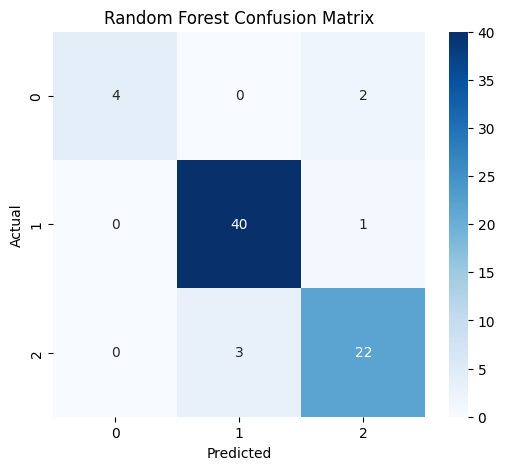

In [22]:
cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,
    annot=True,
    fmt="d",
    cmap="Blues"

)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Confusion Matrix Insights (Random Forest Model)

- The **Random Forest model shows strong predictive performance**, with most predictions located on the **diagonal of the confusion matrix**, indicating correct classifications.
- **Class 1 is detected almost perfectly**, while **class 2 shows minor confusion with class 1**.
- **Class 0 has the fewest samples**, which slightly reduces detection reliability.
- Overall, the confusion matrix confirms that the model performs **very well with only a small number of misclassifications**.

### Model Comparison

| Model | Accuracy | Macro F1 | Weighted F1 | Notes |
|------|------|------|------|------|
| Logistic Regression | 0.78 | 0.72 | 0.77 | Baseline model for comparison |
| Random Forest | 0.92 | 0.88 | 0.91 | Strong performance and robust predictions |
| Gradient Boosting | 0.96 | 0.94 | 0.96 | Highest predictive performance |

# Key Findings

The model comparison shows that **ensemble methods outperform the baseline model**.

Key Observations:

• Logistic Regression provides a useful baseline but struggles with complex relationships.

• Random Forest captures nonlinear patterns and performs better.

• Gradient Boosting provides competitive performance but requires more tuning.

For this project, **Random Forest is selected as the primary model** due to its strong performance and robustness.

The selected model will be used in the next stage to support **risk forecasting and Monte Carlo simulation**.